In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_10x_h5("../data/neuron_10k_v3_filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
adata

C:\Users\dr25624\AppData\Local\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 11843 × 31053
    var: 'gene_ids', 'feature_types', 'genome'

In [3]:
adata.obs.head()

""
AAACCCAAGCAACTCT-1
AAACCCACACGCGGTT-1
AAACCCACAGCATACT-1
AAACCCACATACCATG-1
AAACCCAGTCGCACAC-1


In [4]:
adata.var.head()

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,mm10
Gm1992,ENSMUSG00000089699,Gene Expression,mm10
Gm37381,ENSMUSG00000102343,Gene Expression,mm10
Rp1,ENSMUSG00000025900,Gene Expression,mm10
Sox17,ENSMUSG00000025902,Gene Expression,mm10


In [5]:
# Filtering low-quality cells and genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

In [7]:
# Telling scanpy where to save figures
sc.settings.figdir = "../figures"

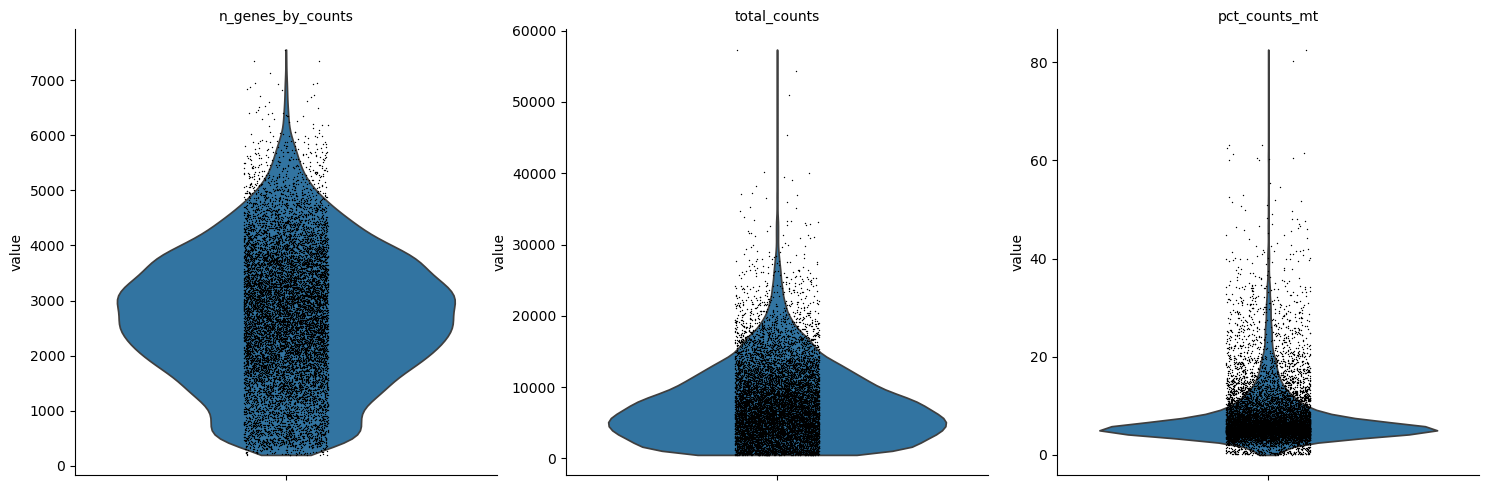

In [8]:
# Plotting QC metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    multi_panel=True
)

In [9]:
# Normalizing the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [10]:
# Selecting highly variable genes
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)
adata = adata[:, adata.var.highly_variable]

C:\Users\dr25624\AppData\Local\anaconda3\Lib\functools.py:934: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\dr25624\AppData\Local\anaconda3\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


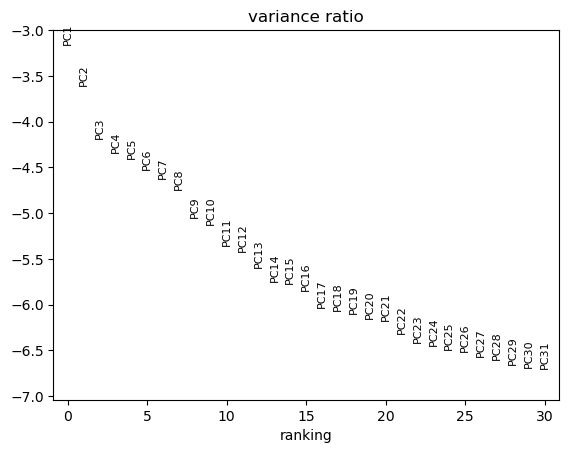

In [11]:
# Dimensionality reduction with a PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, log=True)

In [12]:
# Constructing a neighbor graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

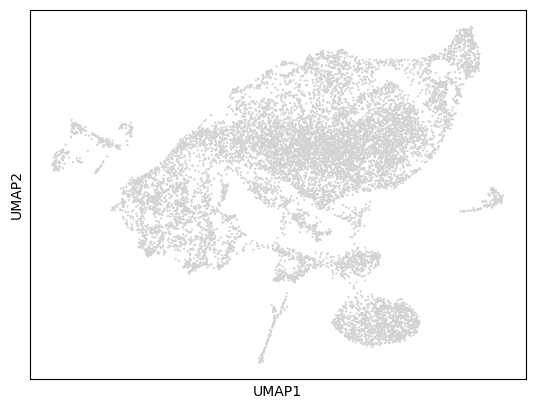

In [13]:
# UMAP Visualization
sc.tl.umap(adata)
sc.pl.umap(adata)

In [14]:
pip install leidenalg

Note: you may need to restart the kernel to use updated packages.


C:\Users\dr25624\AppData\Local\Temp\ipykernel_64840\3038957830.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


C:\Users\dr25624\AppData\Local\Temp\ipykernel_64840\3038957830.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color="leiden", save="_clusters.png")


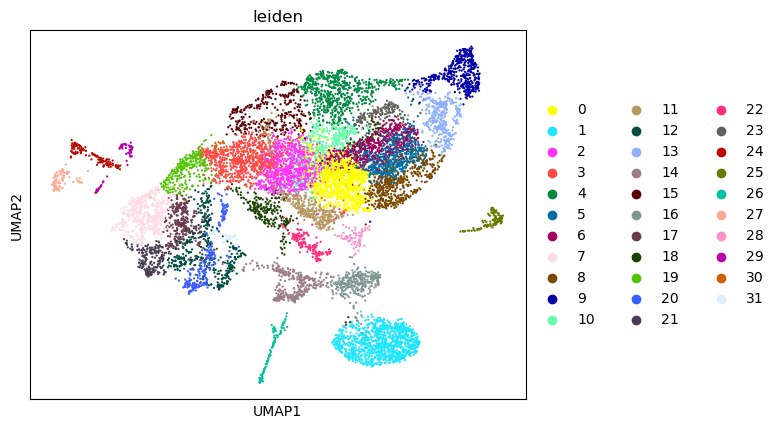

In [15]:
# Leiden clustering
sc.tl.leiden(adata)
sc.pl.umap(adata, color="leiden", save="_clusters.png")

C:\Users\dr25624\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\dr25624\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\dr25624\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\dr25624\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\dr25624\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchange

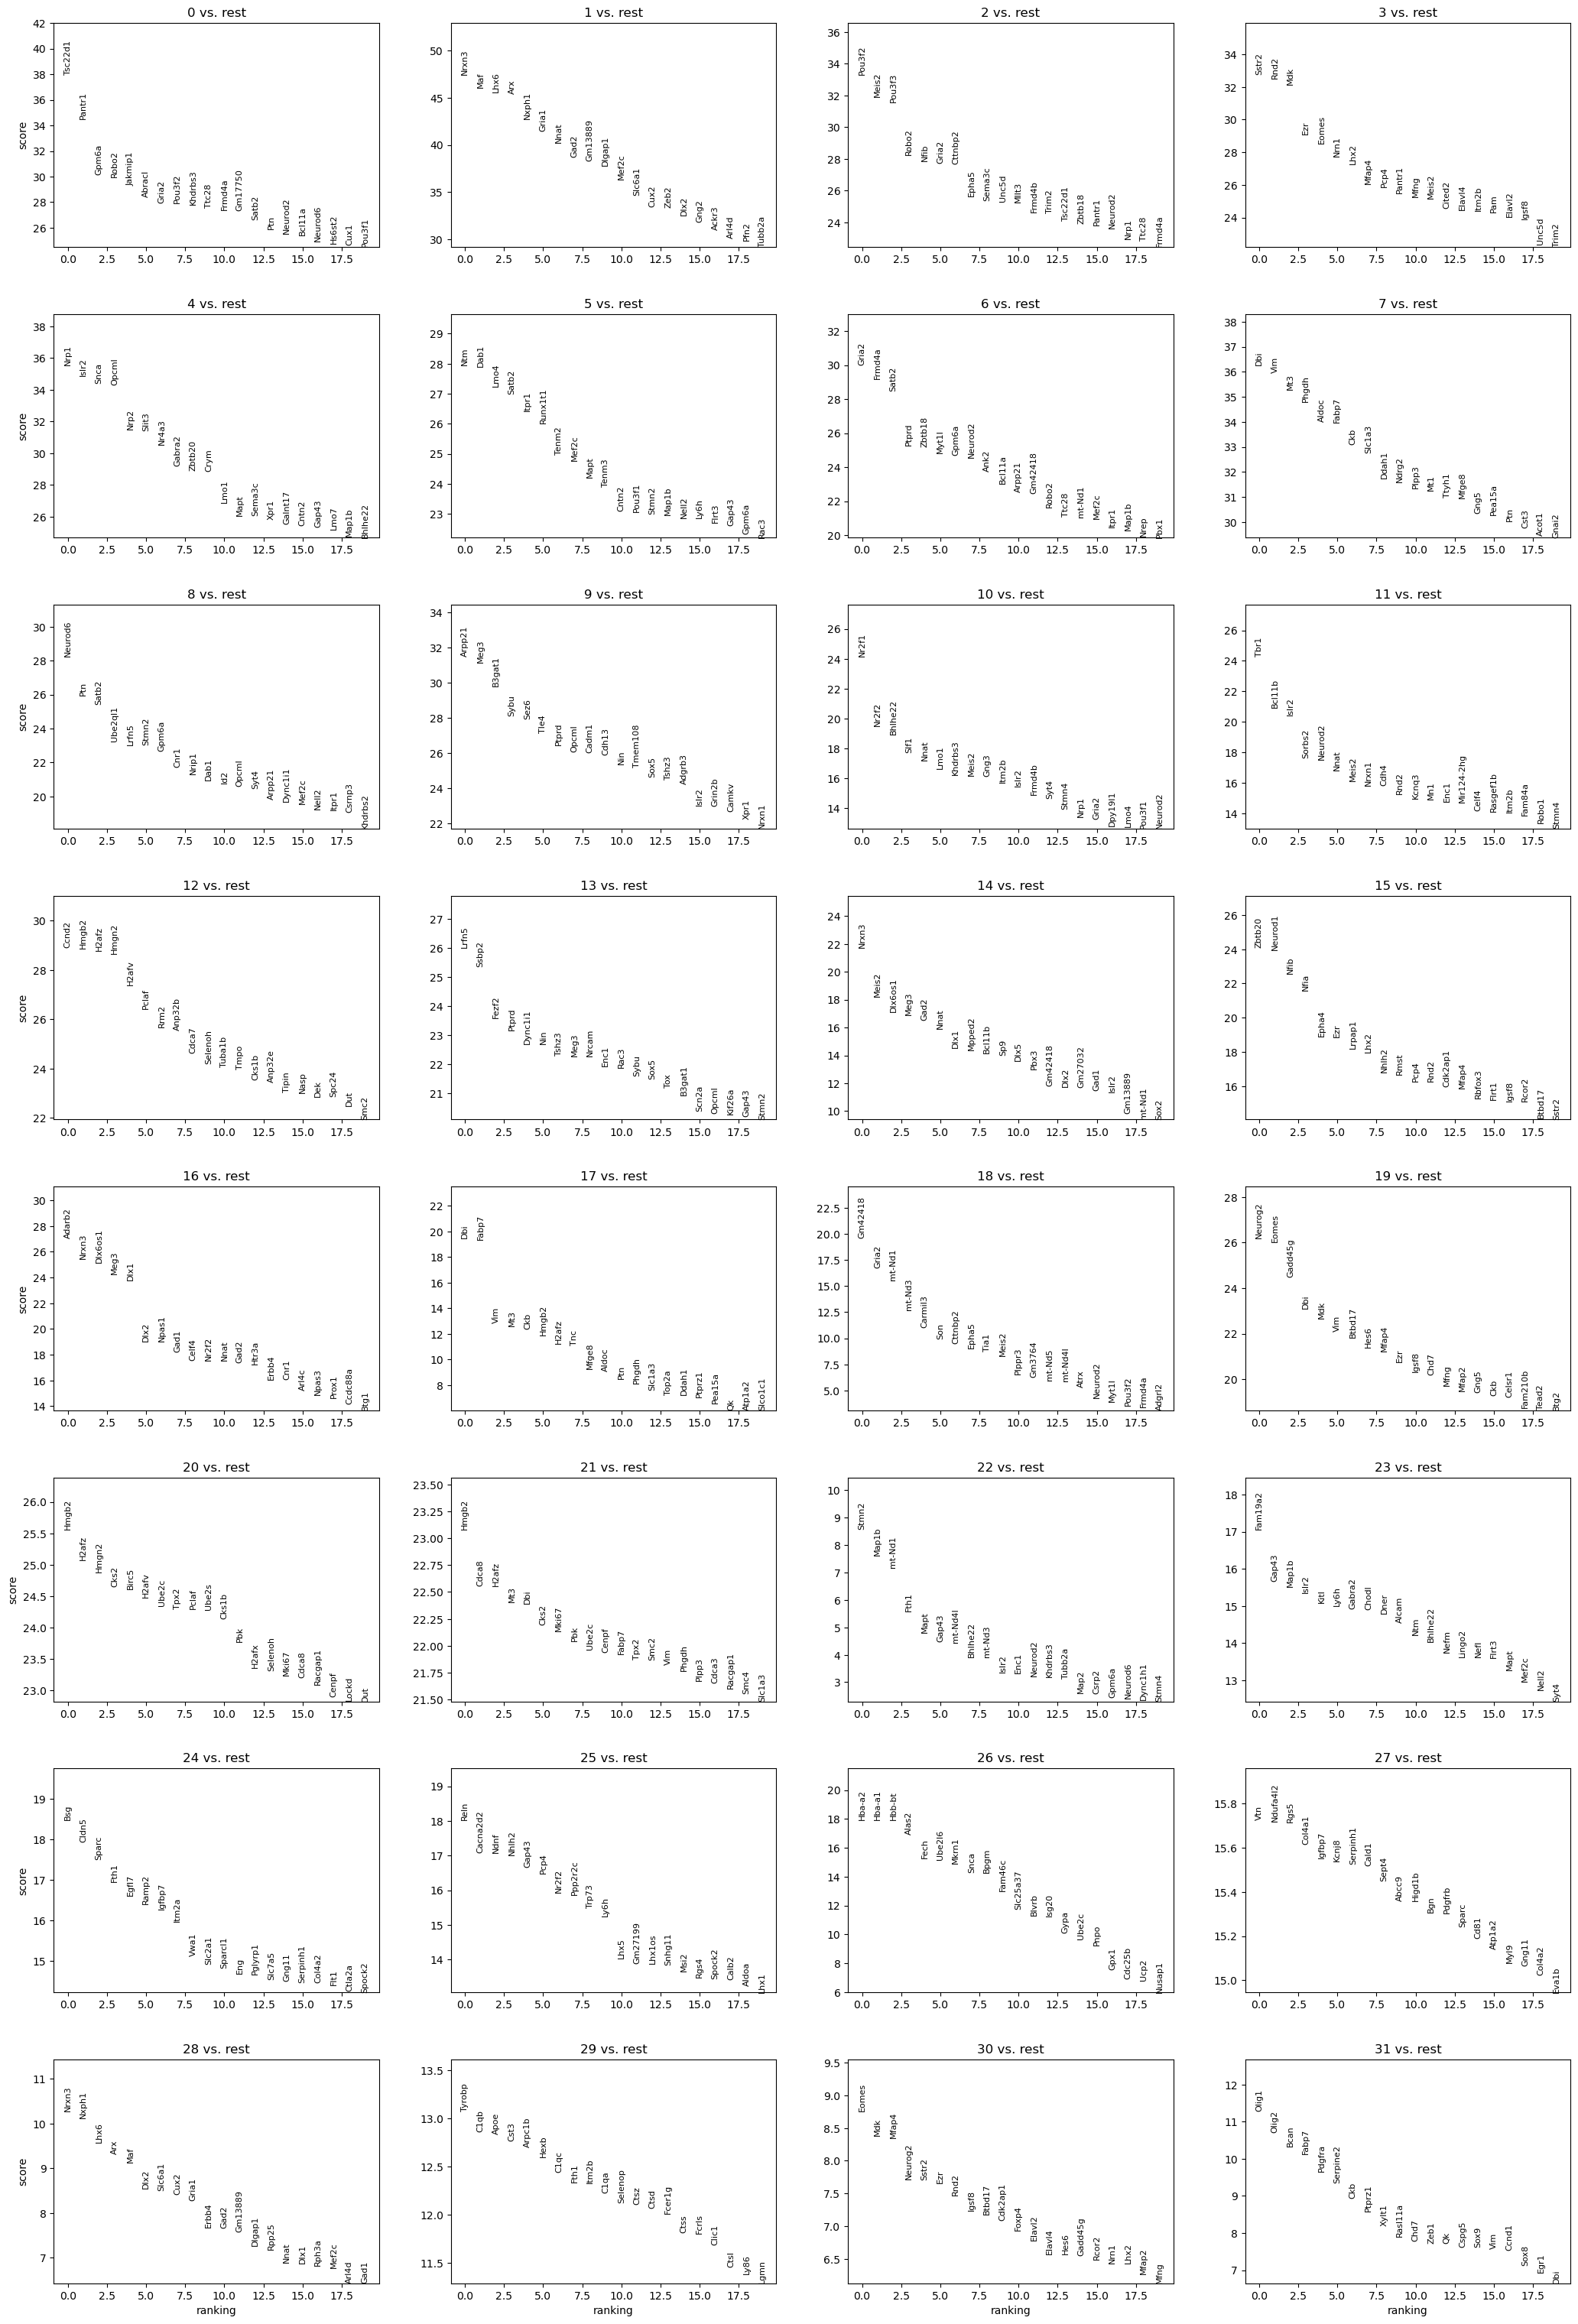

In [16]:
# Marker gene identification
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [17]:
markers = sc.get.rank_genes_groups_df(adata, None)
markers.head(n=10)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Tsc22d1,37.974545,NaN,0.000000e+00,0.000000e+00
1,0,Pantr1,34.498672,NaN,8.397546e-261,1.301200e-257
2,0,Gpm6a,30.154045,NaN,9.493358e-200,9.806639e-197
3,0,Robo2,29.957550,NaN,3.508528e-197,2.718232e-194
4,0,Jakmip1,29.298744,NaN,1.076025e-188,6.669203e-186
5,0,Abracl,28.406464,NaN,1.682620e-177,8.690731e-175
6,0,Gria2,27.960421,NaN,4.924421e-172,2.180112e-169
7,0,Pou3f2,27.930922,NaN,1.124178e-171,4.354784e-169
8,0,Khdrbs3,27.787642,NaN,6.118388e-170,2.106765e-167
9,0,Ttc28,27.584127,NaN,1.725177e-167,5.346324e-165


In [18]:
# Count cells per cluster
adata.obs["leiden"].value_counts()

leiden
0     1036
1     1036
2      838
3      738
4      611
5      575
6      563
7      499
8      497
9      465
10     391
11     388
12     370
13     361
14     329
15     328
16     324
17     288
18     276
19     270
20     244
21     202
22     181
23     158
24     126
25     114
26     108
27      89
28      72
29      67
30      53
31      51
Name: count, dtype: int64

Text(0.5, 1.0, 'Cell counts per cluster')

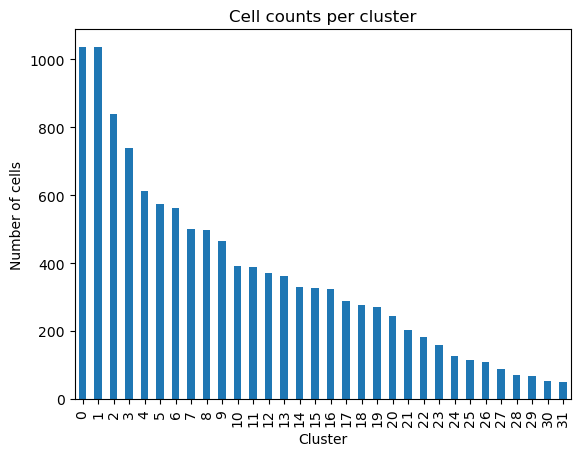

In [19]:
# Visualize cluster distribution
import matplotlib.pyplot as plt
adata.obs["leiden"].value_counts().sort_index().plot.bar()
plt.xlabel("Cluster")
plt.ylabel("Number of cells")
plt.title("Cell counts per cluster")

In [20]:
for cluster in adata.obs["leiden"].cat.categories:
    print("\nCluster", cluster)
    print(sc.get.rank_genes_groups_df(adata, group=cluster).head(5))


Cluster 0
     names     scores  logfoldchanges          pvals      pvals_adj
0  Tsc22d1  37.974545             NaN   0.000000e+00   0.000000e+00
1   Pantr1  34.498672             NaN  8.397546e-261  1.301200e-257
2    Gpm6a  30.154045             NaN  9.493358e-200  9.806639e-197
3    Robo2  29.957550             NaN  3.508528e-197  2.718232e-194
4  Jakmip1  29.298744             NaN  1.076025e-188  6.669203e-186

Cluster 1
   names     scores  logfoldchanges  pvals  pvals_adj
0  Nrxn3  47.435658             NaN    0.0        0.0
1    Maf  46.041149             NaN    0.0        0.0
2   Lhx6  45.564743             NaN    0.0        0.0
3    Arx  45.387043             NaN    0.0        0.0
4  Nxph1  42.776772             NaN    0.0        0.0

Cluster 2
    names     scores  logfoldchanges          pvals      pvals_adj
0  Pou3f2  33.316460             NaN  2.230566e-243  6.912524e-240
1   Meis2  31.921240             NaN  1.354799e-223  2.099262e-220
2  Pou3f3  31.582846             N

In [21]:
# Creating a mapping of cluster to cell type
celltype_map = {
"1": "Inhibitory neurons",
"14": "Inhibitory neurons",
"16": "Inhibitory neurons",
"28": "Inhibitory neurons",

"5": "Excitatory neurons",
"6": "Excitatory neurons",
"8": "Excitatory neurons",
"11": "Excitatory neurons",
"13": "Excitatory neurons",

"7": "Astrocytes",
"17": "Astrocytes",

"31": "OPCs",

"29": "Microglia",

"24": "Endothelial cells",

"26": "Erythrocytes"
}

In [22]:
# Annotation
adata.obs["cell_type"] = adata.obs["leiden"].map(celltype_map)
adata.obs["cell_type"] = adata.obs["cell_type"].fillna("Unknown")
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

categories: Astrocytes, Endothelial cells, Erythrocytes, etc.
var_group_labels: 0, 1, 2, etc.


C:\Users\dr25624\AppData\Local\Temp\ipykernel_64840\3889661240.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_genes_groups_dotplot(


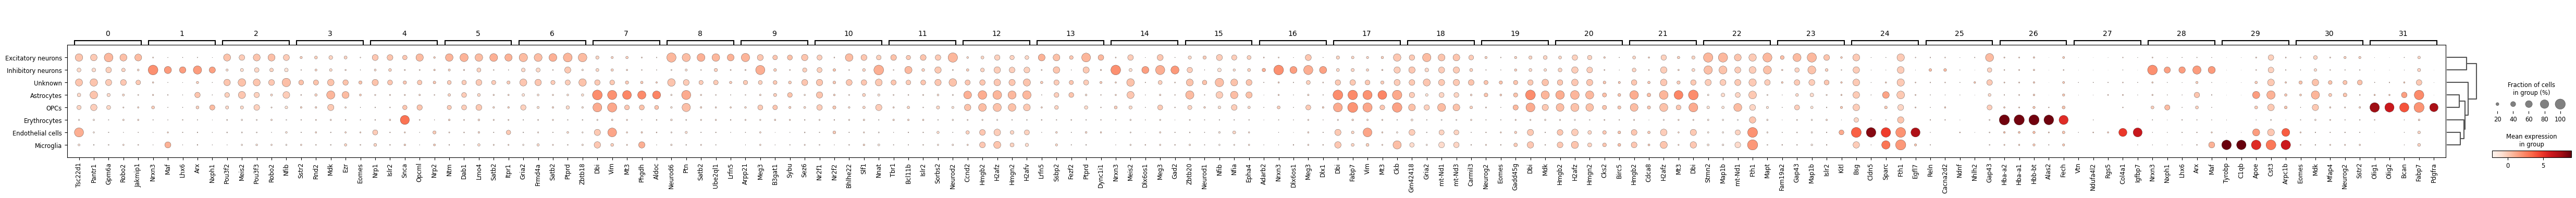

In [23]:
# Dotplot visualization
sc.tl.dendrogram(adata, groupby="cell_type")
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    groupby="cell_type",
    save="_marker_dotplot.png"
)

categories: Astrocytes, Endothelial cells, Erythrocytes, etc.
var_group_labels: 0, 1, 2, etc.


C:\Users\dr25624\AppData\Local\Temp\ipykernel_64840\1737884307.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_genes_groups_heatmap(


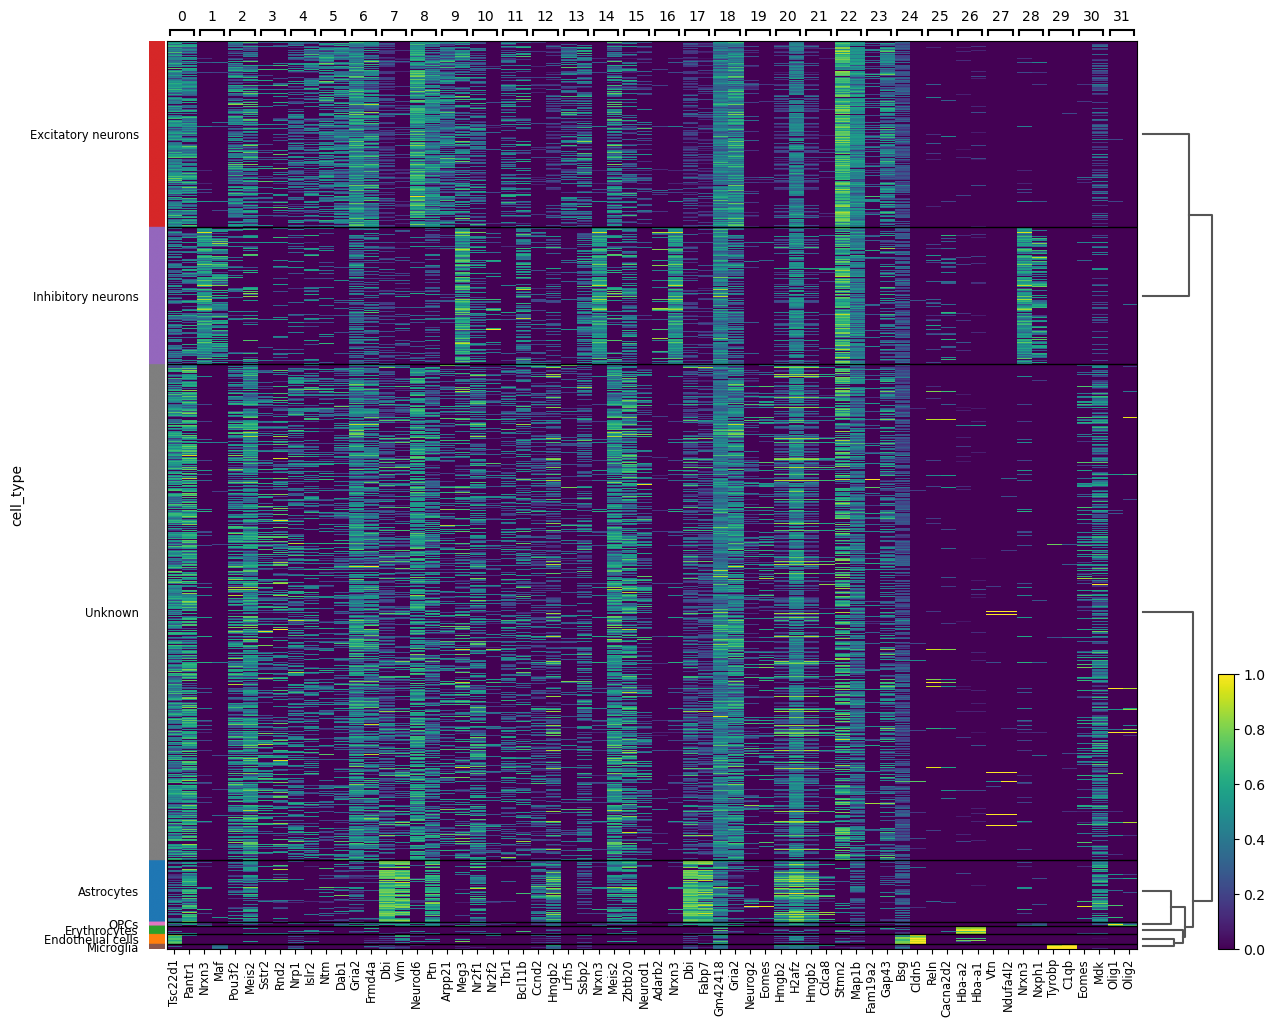

In [24]:
# Heatmap of marker genes
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=2,
    groupby="cell_type",
    standard_scale="var",
    figsize=(14,12),
    show_gene_labels=True,
    save="_marker_heatmap.png"
)

C:\Users\dr25624\AppData\Local\Temp\ipykernel_64840\676706141.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


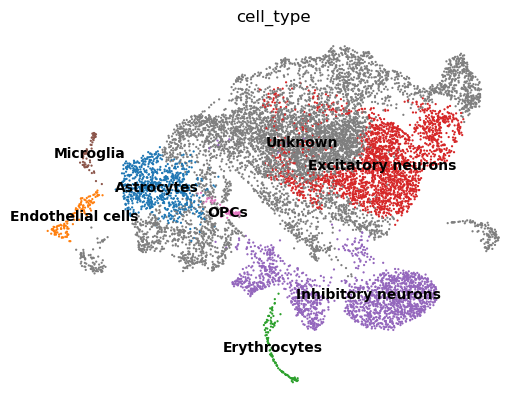

In [25]:
# Plotting annotated clusters 
sc.tl.umap(adata, min_dist=0.7)
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data",
    frameon=False, 
    save="_celltypes.png"
)

In [26]:
adata.write("../data/mouse_brain_processed.h5ad")